<a href="https://colab.research.google.com/github/Christianib003/rekomai/blob/clint/notebooks/data_processing_formative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 1: DATA MERGING

### SUBTASK 1: Exploratory Data Analysis (EDA) of Tabular Data

In [1]:
# Basic data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline
%matplotlib inline

# Set aesthetics
sns.set(style="whitegrid")


In [2]:
# Load datasets
df_profiles = pd.read_csv('https://raw.githubusercontent.com/Christianib003/rekomai/refs/heads/clint/data/customer-info/Customer%20Social%20Profiles.csv')
df_transactions = pd.read_csv('https://raw.githubusercontent.com/Christianib003/rekomai/refs/heads/clint/data/customer-info/Customer%20Transactions.csv')


In [3]:
# Display first few rows of each dataframe
display(df_profiles.head())
display(df_transactions.head())


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


In [4]:
# Summary of social profiles
print("📊 Social Profiles Summary:")
display(df_profiles.info())
display(df_profiles.describe(include='all'))

# Summary of transactions
print("\n🧾 Transactions Summary:")
display(df_transactions.info())
display(df_transactions.describe(include='all'))


📊 Social Profiles Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id_new          155 non-null    object 
 1   social_media_platform    155 non-null    object 
 2   engagement_score         155 non-null    int64  
 3   purchase_interest_score  155 non-null    float64
 4   review_sentiment         155 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 6.2+ KB


None

,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
count,155,155,155.000000,155.000000,155
unique,84,5,NaN,NaN,3
top,A155,Twitter,NaN,NaN,Positive
freq,7,38,NaN,NaN,63
mean,NaN,NaN,75.606452,3.152903,NaN
std,NaN,NaN,14.568021,1.142867,NaN
min,NaN,NaN,50.000000,1.000000,NaN
25%,NaN,NaN,63.500000,2.350000,NaN
50%,NaN,NaN,77.000000,3.200000,NaN
75%,NaN,NaN,87.500000,4.100000,NaN



🧾 Transactions Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id_legacy  150 non-null    int64  
 1   transaction_id      150 non-null    int64  
 2   purchase_amount     150 non-null    int64  
 3   purchase_date       150 non-null    object 
 4   product_category    150 non-null    object 
 5   customer_rating     140 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 7.2+ KB


None

,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
count,150.000000,150.000000,150.000000,150,150,140.00000
unique,NaN,NaN,NaN,150,5,NaN
top,NaN,NaN,NaN,2024-01-01,Sports,NaN
freq,NaN,NaN,NaN,1,35,NaN
mean,148.760000,1075.500000,280.780000,NaN,NaN,2.98500
std,30.046425,43.445368,121.329595,NaN,NaN,1.20699
min,100.000000,1001.000000,51.000000,NaN,NaN,1.00000
25%,121.250000,1038.250000,179.000000,NaN,NaN,1.95000
50%,150.500000,1075.500000,274.000000,NaN,NaN,3.00000
75%,174.750000,1112.750000,388.500000,NaN,NaN,4.00000


In [5]:
# Check missing values
print("Missing values in Social Profiles:\n", df_profiles.isnull().sum())
print("\nMissing values in Transactions:\n", df_transactions.isnull().sum())


Missing values in Social Profiles:
 customer_id_new            0
social_media_platform      0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
dtype: int64

Missing values in Transactions:
 customer_id_legacy     0
transaction_id         0
purchase_amount        0
purchase_date          0
product_category       0
customer_rating       10
dtype: int64


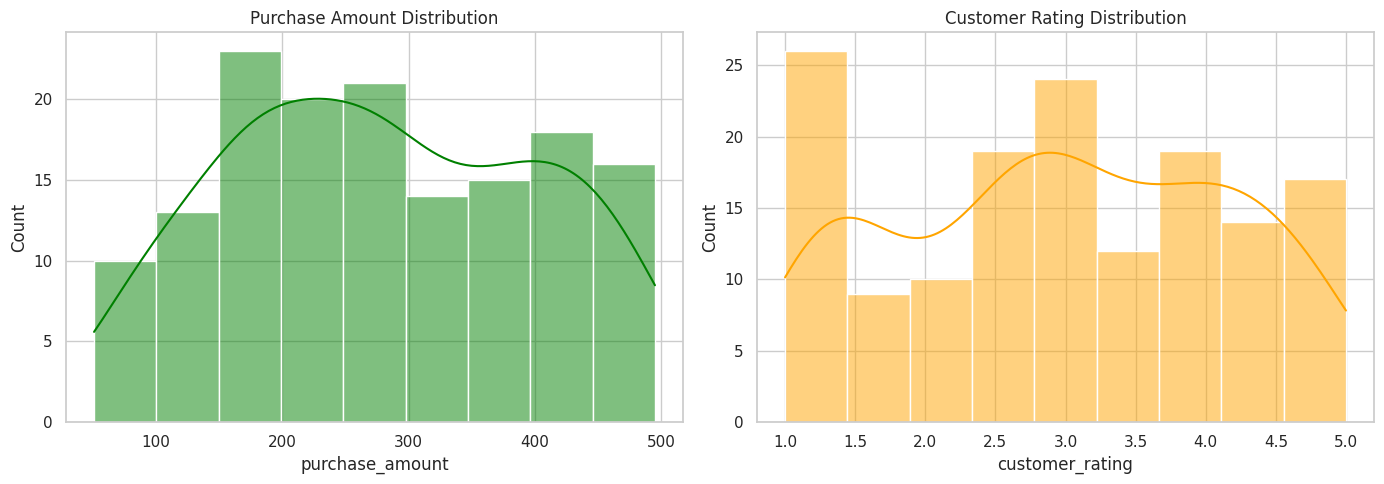

In [9]:
# Purchase amount and customer rating
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_transactions['purchase_amount'], kde=True, color='green')
plt.title('Purchase Amount Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_transactions['customer_rating'], kde=True, color='orange')
plt.title('Customer Rating Distribution')

plt.tight_layout()
plt.show()


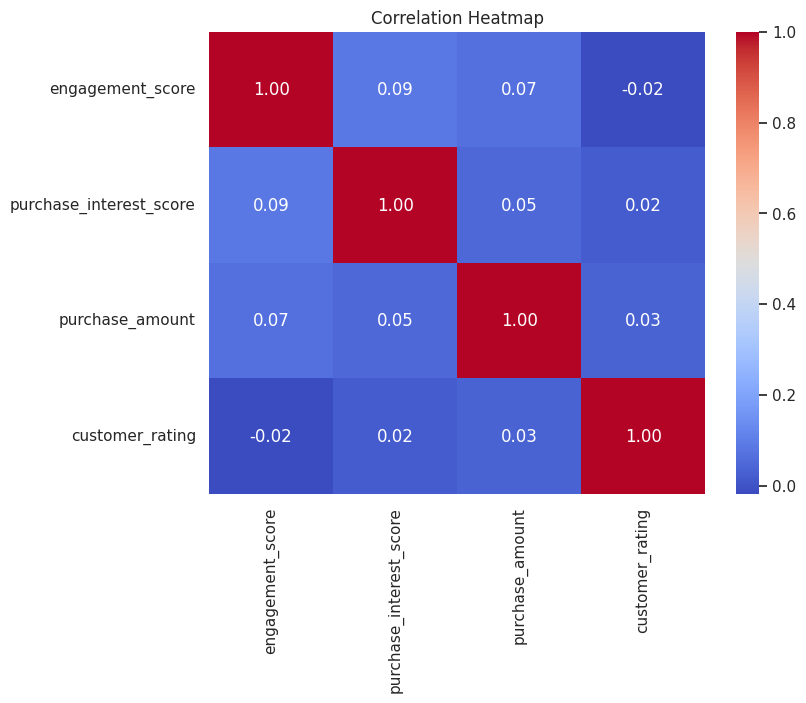

In [10]:
# Combine numeric fields from both datasets for correlation
combined_numeric = pd.concat([
    df_profiles[['engagement_score', 'purchase_interest_score']],
    df_transactions[['purchase_amount', 'customer_rating']]
], axis=1)

plt.figure(figsize=(8, 6))
sns.heatmap(combined_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


### SUBTASK 2: DATA CLEANING & MERGING

In [11]:
# Calculate mean rating per product category
category_means = df_transactions.groupby('product_category')['customer_rating'].mean()

# Fill missing values using the category-specific mean
df_transactions['customer_rating'] = df_transactions.apply(
    lambda row: category_means[row['product_category']] if pd.isnull(row['customer_rating']) else row['customer_rating'],
    axis=1
)

# Confirm the fix
print("Remaining missing values:", df_transactions['customer_rating'].isnull().sum())

Remaining missing values: 0


In [12]:
# Rename ID columns to a common name
df_profiles.rename(columns={'customer_id_new': 'customer_id'}, inplace=True)
df_transactions.rename(columns={'customer_id_legacy': 'customer_id'}, inplace=True)


In [13]:
# Check ID formats
print(df_profiles['customer_id'].head())
print(df_transactions['customer_id'].head())


0    A178
1    A190
2    A150
3    A162
4    A197
Name: customer_id, dtype: object
0    151
1    192
2    114
3    171
4    160
Name: customer_id, dtype: int64


In [14]:
# Extract numeric part from profile ID
df_profiles['customer_id'] = df_profiles['customer_id'].str.extract('(\d+)').astype(int)


In [15]:
# Confirm both IDs are numeric
print(df_profiles['customer_id'].dtype)
print(df_transactions['customer_id'].dtype)


int64
int64


In [16]:
# Merge datasets on 'customer_id'
df_merged = pd.merge(df_profiles, df_transactions, on='customer_id', how='inner')

# Show shape and preview
print(f"Merged dataset shape: {df_merged.shape}")
df_merged.head()


Merged dataset shape: (219, 10)


,customer_id,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,190,Twitter,82,4.8,Neutral,1031,333,2024-01-31,Groceries,3.800000
1,190,Twitter,82,4.8,Neutral,1140,401,2024-05-19,Sports,4.900000
2,150,Facebook,96,1.6,Positive,1042,389,2024-02-11,Sports,3.194118
3,150,Facebook,96,1.6,Positive,1046,177,2024-02-15,Books,3.600000
4,162,Twitter,89,2.6,Positive,1079,101,2024-03-19,Books,4.200000


In [17]:
# Check for duplicate rows
print("Duplicates:", df_merged.duplicated().sum())

# Check for any remaining missing values
print("Missing values:\n", df_merged.isnull().sum())


Duplicates: 6
Missing values:
 customer_id                0
social_media_platform      0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
transaction_id             0
purchase_amount            0
purchase_date              0
product_category           0
customer_rating            0
dtype: int64


In [ ]:
# Save cleaned, merged dataset
df_merged.to_csv('merged_dataset.csv', index=False)
